In [2]:
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd

import torch as th
from torch import nn
import seaborn as sns

In [3]:
df = pd.read_csv('malicious_phish.csv')
df.head()

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [4]:
df.describe()

,url,type
count,651191,651191
unique,641119,4
top,http://style.org.hc360.com/css/detail/mysite/s...,benign
freq,180,428103


In [5]:
df['type'].value_counts()

type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Text(0, 0.5, 'Count')

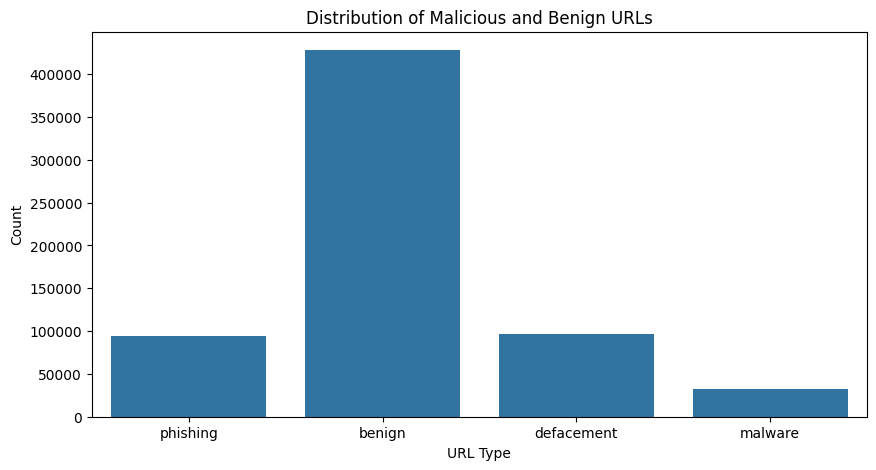

In [6]:
plt.figure(figsize=(10,5))
plt.title('Distribution of Malicious and Benign URLs')
sns.countplot(x='type',data = df)
plt.xlabel('URL Type')
plt.ylabel('Count')


**Feature Engineering**
 
We will now extract features from URLs, and use them to train machine learning model

has_ip_address: It's common for malicious links to have an ip address instead of domain name, this function if url has a IP address in domain.

In [7]:
import re  

def has_ip_address(url):
    # Regular expression to match IPv4 addresses
    match = re.search(
        '(([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.'
        '([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\/)|'  # IPv4
        '((0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\/)' # IPv4 in hexadecimal
        '(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}', url) # IPv6

    if match:
        return 1
    else:
        return 0
    
df['has_ip'] = df['url'].apply(has_ip_address)
df[df['has_ip'] == 1].head()
    

,url,type,has_ip
10408,http://219.232.244.89/intl/update/error_login.htm,phishing,1
12441,boards.ancestry.com/topics.ethnic.natam.nation...,benign,1
12853,http://www.controlyourbreath.com/new/css_/img/...,phishing,1
13161,http://www.reqntpvw.com/Public/softs/everythin...,malware,1
14915,http://66.208.115.70/images/index.asp,phishing,1


In [8]:
df['has_ip'].value_counts()

has_ip
0    643898
1      7293
Name: count, dtype: int64

check_google_index: Will check if the URL is in google search console

In [9]:
from googlesearch import search

def check_google_index(url):
    site = search(url, 5)
    if site:
        return 1
    else:
        return 0

df['in_google_index'] = df['url'].apply(check_google_index)

    

count_dot: checks, if the url has multiple subdomains, by checking the ammount of dots, url's with three or more sub domains are more likely to be malicious 

In [10]:
def count_dot(url):
    return url.count('.')

df['dot_count'] = df['url'].apply(count_dot)

In [11]:
df['dot_count'].value_counts()

dot_count
2     236038
1     219105
3     129667
4      40227
5       9436
6       5729
7       3570
8       1566
9       1150
10      1114
11       973
12       757
13       505
14       379
15       259
16       144
20       129
17       118
19        88
18        70
0         61
22        24
24        22
21        18
23        10
25         9
36         5
27         4
26         4
35         3
42         3
31         1
37         1
34         1
28         1
Name: count, dtype: int64

count_www: Counts the number of www in url, most safe sites will have only one instance of www.

In [15]:
def count_www(url):
    return url.count('www')

df['www_count']=df['url'].apply(count_www)

In [16]:
df['www_count'].value_counts()

www_count
0    525525
1    124178
2      1422
3        58
4         7
5         1
Name: count, dtype: int64

count@: Counts the number of @ in url.

In [17]:
def count_at(url):
    return url.count('@')

df['at_count'] = df['url'].apply(count_at)

In [18]:
df['at_count'].value_counts()

at_count
0     649845
1       1290
2         40
3          9
4          3
10         3
6          1
Name: count, dtype: int64

count_directory: The more directories, the more likely a url is suspicious. 

In [27]:
from urllib.parse import urlparse

def count_directory(url):
    urldir=urlparse(url).path
    return urldir.count('/')

df['directory_count'] = df['url'].apply(count_directory)

In [28]:
df['directory_count'].value_counts()

directory_count
1     208263
2     185322
3     120164
4      53510
5      35379
0      23046
6      14204
7       5671
8       2326
10      1362
9        966
11       343
13       176
12       165
14       161
16        50
15        32
22        12
18        10
17         9
21         5
19         3
24         2
23         2
27         2
39         1
28         1
25         1
20         1
32         1
34         1
Name: count, dtype: int64

count_embedded_domain: Multiple embededded domains generally indicates a link is suspicious 

In [31]:
def count_embedded_domain(url):
    urldir=urlparse(url).path
    return urldir.count('//')

df['embedded_domain_count'] = df['url'].apply(count_embedded_domain)

In [32]:
df['embedded_domain_count'].value_counts()

embedded_domain_count
0    650205
1       974
2        12
Name: count, dtype: int64

suspicious_words: Checks for suspicious words (login, Paypal, bank, etc) which indicate url may be malicious

In [33]:
def suspicious_words(url):
    suspicious_terms = ['login', 'signin', 'secure', 'account', 'update', 'free', 'verify', 'ebayisapi', 'bank', 'ebay', 'paypal', 'click', 'confirm', 'webscr',]
    url_lower = url.lower()
    for term in suspicious_terms:
        if term in url_lower:
            return 1
    return 0

df['suspicious_word'] = df['url'].apply(suspicious_words)

In [34]:
df['suspicious_word'].value_counts()

suspicious_word
0    601202
1     49989
Name: count, dtype: int64

shortening_url: checks if url uses URL shortening services (bit. \ly , goo.gl)

In [39]:
def shortening_url(url):
    shorteners = [
        "bit.ly", "goo.gl", "shorte.st", "go2l.ink", "x.co", "ow.ly", "t.co",
        "tinyurl", "tr.im", "is.gd", "cli.gs", "yfrog.com", "migre.me",
        "ff.im", "tiny.cc", "url4.eu", "twit.ac", "su.pr", "twurl.nl",
        "snipurl.com", "short.to", "BudURL.com", "ping.fm", "post.ly",
        "Just.as", "bkite.com", "snipr.com", "fic.kr", "loopt.us",
        "doiop.com", "short.ie", "kl.am", "wp.me", "rubyurl.com",
        "om.ly", "to.ly", "bit.do", "lnkd.in", "db.tt", "qr.ae",
        "adf.ly", "bitly.com", "cur.lv", "tinyurl.com", "ity.im",
        "q.gs", "po.st", "bc.vc", "twitthis.com", "u.to", "j.mp",
        "buzurl.com", "cutt.us", "u.bb", "yourls.org", "prettylinkpro.com",
        "scrnch.me", "filoops.info", "vzturl.com", "qr.net", "1url.com",
        "tweez.me", "v.gd", "link.zip.net"
    ]

    for service in shorteners:
        if service in url:
            return 1

    return 0
    
df['shortening_url'] = df['url'].apply(shortening_url)

In [40]:
df['shortening_url'].value_counts()

shortening_url
0    611436
1     39755
Name: count, dtype: int64

count_https: Presence of https protocol generally indicates a website is safe.

In [41]:
def count_https(url):
    return url.count('https')

df['https_count'] = df['url'].apply(count_https)

In [42]:
df['https_count'].value_counts()

https_count
0    634768
1     16197
2       183
3        34
5         6
4         3
Name: count, dtype: int64

count_http: Presence of multiple http in url indicates it may be malicious.

In [43]:
def count_http(url):
    return url.count('http')

df['http_count'] = df['url'].apply(count_http)

In [44]:
df['http_count'].value_counts()

http_count
0    461527
1    186625
2      2564
3       455
4        11
9         6
6         2
5         1
Name: count, dtype: int64

count_percent: Safe sites generally will contain less % symbols than malicious sites.

In [45]:
def count_percent(url):
    return url.count('%')

df['percent_count'] = df['url'].apply(count_percent)

In [46]:
df['percent_count'].value_counts()

percent_count
0      623991
1        5824
2        4981
3        2415
6        1710
        ...  
146         1
231         1
198         1
128         1
149         1
Name: count, Length: 124, dtype: int64

count_question: ? are followed by query string that contains data to be passed to server, the more instances of it the more suspicious it's likely to be. 

In [47]:
def count_question(url):
    return url.count('?')   

df['question_count'] = df['url'].apply(count_question)

In [48]:
df['question_count'].value_counts()

question_count
0     511013
1     134983
2       5065
3         69
4         25
5         11
7          7
6          3
11         3
8          3
12         2
13         2
14         1
15         1
20         1
10         1
17         1
Name: count, dtype: int64

count_dash: dashes are added to make malicious websites look legit.

In [49]:
def count_dash(url):
    return url.count('-')

df['dash_count'] = df['url'].apply(count_dash)

In [50]:
df['dash_count'].value_counts()

dash_count
0     377210
1     104187
2      44061
3      27016
4      22128
5      16145
6      12277
7       9347
8       8400
9       6775
10      6050
11      4710
12      3567
13      2769
14      1990
15      1414
16       924
17       694
18       411
19       269
20       186
21       151
22       100
23        88
24        61
25        42
26        35
27        34
28        32
29        26
31        16
30        12
34         9
32         9
35         5
38         5
33         5
47         4
36         4
41         4
40         3
37         3
42         3
39         3
64         3
50         1
48         1
87         1
54         1
Name: count, dtype: int64

count_equal: Equal (=) signs indicate passing of variable values from one page to another, the more present the higher chance an url is suspicious.

In [51]:
def count_equal(url):
    return url.count('=')

df['equal_count'] = df['url'].apply(count_equal)

In [52]:
df['equal_count'].value_counts()    

equal_count
0     510898
1      54747
2      23212
4      21442
3      14951
5      13443
6       5685
9       2391
7       1981
8       1340
10       344
11       212
12       163
19       127
13       118
14        68
15        19
16        10
17         9
18         7
22         7
34         4
24         4
28         3
20         1
21         1
39         1
29         1
51         1
26         1
Name: count, dtype: int64

url_length: Malicious links may contain longer urls to hide domain names

In [53]:
def url_length(url):
    return len(url)

df['url_length'] = df['url'].apply(url_length)

In [54]:
df['url_length'].value_counts()

url_length
31      19023
33      14209
34      12243
27      11967
35      11700
        ...  
2175        1
493         1
586         1
463         1
467         1
Name: count, Length: 549, dtype: int64

hostname_length: A longer hostname is also suspicious 

In [58]:
def hostname_length(url):
    hostname = urlparse(url).netloc
    return len(hostname)

df['hostname_length'] = df['url'].apply(hostname_length)

In [59]:
df['hostname_length'].value_counts()

hostname_length
0      463192
15      15950
13      14592
14      14061
20      12039
        ...  
116         1
83          1
100         1
122         1
179         1
Name: count, Length: 134, dtype: int64

first_dir_length: The length of the first directory is also relevant when figuring out if a link is safe or suspicious 

In [60]:
from tld import get_tld


def first_directory_length(url):
    path = urlparse(url).path
    try:
        return len(path.split('/')[1])
    except:  
        return 0
    
df['first_directory_length'] = df['url'].apply(first_directory_length)

In [61]:
df['first_directory_length'].value_counts()

first_directory_length
9      83387
4      80768
0      77782
6      51283
5      50371
       ...  
241        1
206        1
199        1
154        1
230        1
Name: count, Length: 218, dtype: int64

top_level_domain_length: Top level domain is the domain with the highest level in hierachy of DNS, ex: .com, .ca. Most safe urls top level domain length ranges from 2-3.

In [66]:
def top_level_domain(url):
    try:
        return get_tld(url, as_object=True).tld
    except:
        return ''

df['tld']=df['url'].apply(top_level_domain)

def top_level_domain_length(tld):
    try:
        return len(tld)
    except:
        return -1
    
df['tld_length'] = df['tld'].apply(top_level_domain_length)

In [67]:
df['tld'].value_counts()

tld
             475281
com           71689
de            11331
net            9851
nl             6159
              ...  
ninja             1
org.my            1
hopto.org         1
ilawa.pl          1
gratis            1
Name: count, Length: 544, dtype: int64

In [68]:
df['tld_length'].value_counts()

tld_length
0     475281
3      87461
2      58700
6      16612
5       6214
4       5405
12       458
14       297
7        254
9        118
11       101
16        71
8         50
13        42
15        41
10        30
21        18
17         9
26         8
20         4
27         3
30         3
18         2
25         2
22         2
31         2
39         2
34         1
Name: count, dtype: int64

count_digits: Safe urls generally won't have digits in them.

In [69]:
def count_digits(url):
    digits = 0
    for i in url:
        if i.isnumeric():
            digits+=1
    return digits

df['digit_count'] = df['url'].apply(count_digits)

In [70]:
df['digit_count'].value_counts()

digit_count
0      277500
4       41826
2       36989
1       35880
6       34093
        ...  
206         1
286         1
229         1
194         1
151         1
Name: count, Length: 222, dtype: int64

count_letters: The number of letter is also important as attackers many try to increase length of URL to hide URL. 

In [71]:
def count_letters(url):
    letters = 0
    for i in url:
        if i.isalpha():
            letters+=1
    return letters

df['letter_count'] = df['url'].apply(count_letters)

In [72]:
df['letter_count'].value_counts()

letter_count
26     16704
25     16617
27     15503
24     15142
28     15054
       ...  
364        1
772        1
480        1
485        1
343        1
Name: count, Length: 425, dtype: int64